# 🧠 Teen Mental Health — XGBoost Classification
**Dataset:** Teen_Mental_Health_Dataset.csv  
**Target:** `depression_label` (0 = Tidak Depresi, 1 = Depresi)  
**Alur:** Import → EDA → Preprocessing → SMOTE → Training → Evaluasi → Feature Importance

---
## 📦 Cell 1 — Install Library

In [1]:
# Jalankan cell ini jika library belum terinstall
%pip install xgboost imbalanced-learn scikit-learn pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 📚 Cell 2 — Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library berhasil diimport!')
print(f'   XGBoost versi : {xgb.__version__}')

✅ Semua library berhasil diimport!
   XGBoost versi : 3.2.0


---
## 📂 Cell 3 — Load Dataset

In [3]:
# Sesuaikan path jika file CSV tidak satu folder dengan notebook ini
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print('=' * 50)
print(f'  Jumlah baris   : {df.shape[0]}')
print(f'  Jumlah kolom   : {df.shape[1]}')
print('=' * 50)
df.head(10)

  Jumlah baris   : 1200
  Jumlah kolom   : 13


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


---
## 🔍 Cell 4 — Exploratory Data Analysis (EDA)

In [4]:
# Info tipe data dan missing values
print('--- Info Dataset ---')
df.info()
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Statistik Deskriptif ---')
df.describe()

--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 K

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


--- Distribusi Target: depression_label ---
  Kelas 0 : 1169 sampel (97.42%)
  Kelas 1 : 31 sampel (2.58%)


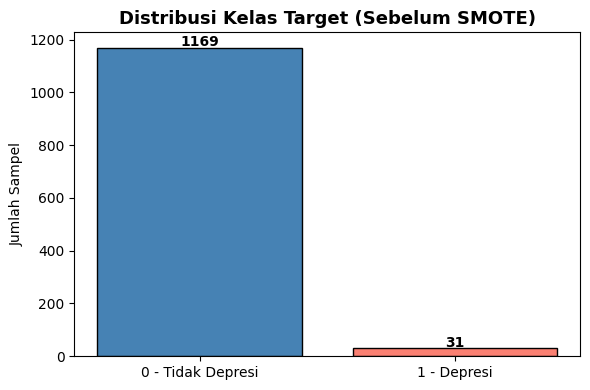

In [5]:
# Distribusi Target (Imbalance Check)
target_counts = df['depression_label'].value_counts()
target_pct    = df['depression_label'].value_counts(normalize=True) * 100

print('--- Distribusi Target: depression_label ---')
for label, count in target_counts.items():
    print(f'  Kelas {label} : {count} sampel ({target_pct[label]:.2f}%)')

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['0 - Tidak Depresi', '1 - Depresi'],
    target_counts.values,
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
for bar, count in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontweight='bold')
plt.title('Distribusi Kelas Target (Sebelum SMOTE)', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

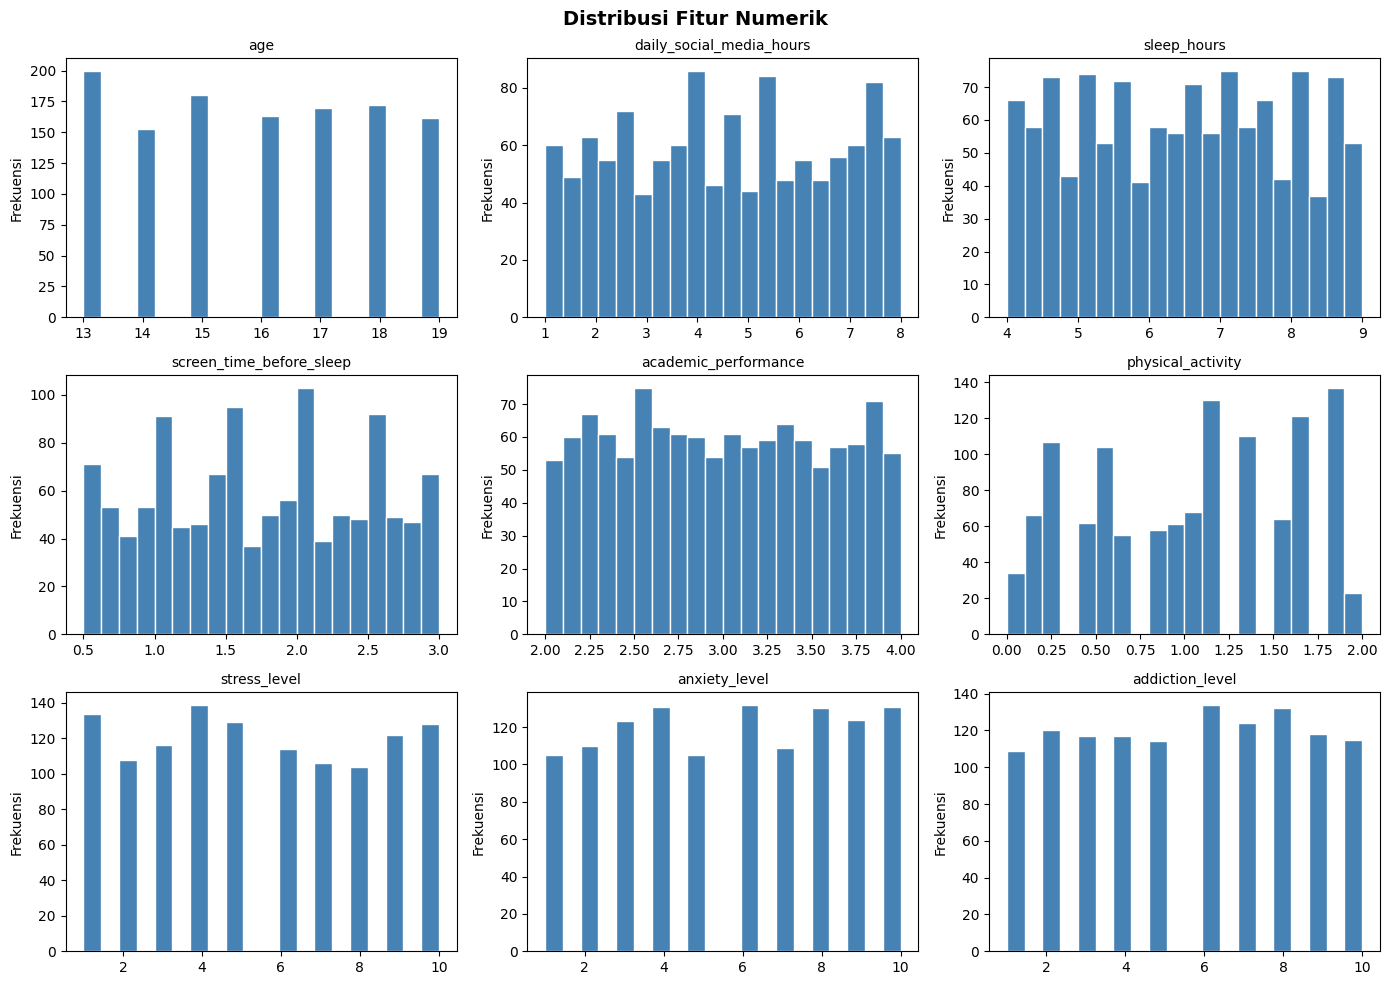

In [6]:
# Distribusi Fitur Numerik
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('depression_label')

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan subplot sisa jika ada
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

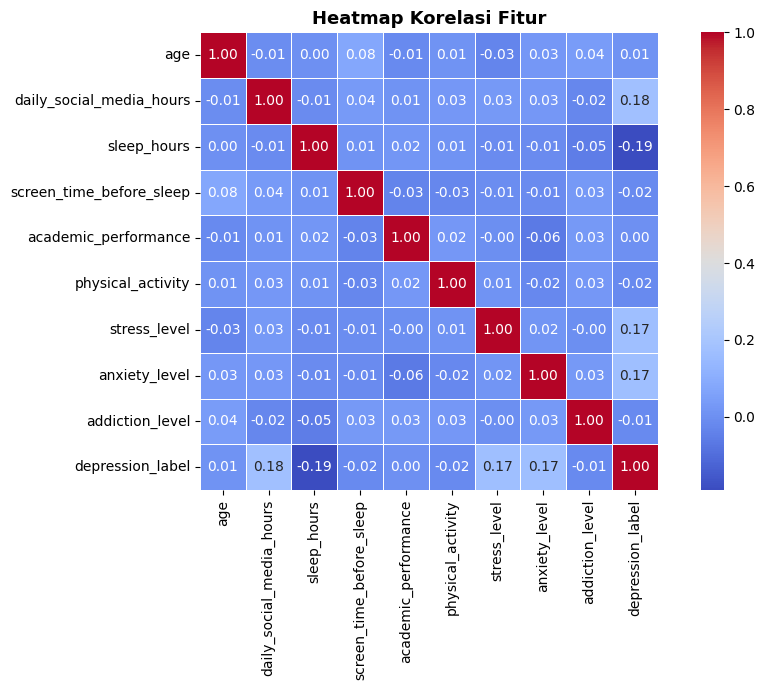

In [7]:
# Heatmap Korelasi
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['depression_label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Cell 5 — Preprocessing

In [8]:
df_model = df.copy()

# Encode kolom kategorikal
le = LabelEncoder()
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'  ✅ Encoded "{col}" -> {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Pisahkan fitur dan target
X = df_model.drop('depression_label', axis=1)
y = df_model['depression_label']

# Split data (stratify agar proporsi kelas terjaga)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print()
print(f'  Total data       : {len(X)}')
print(f'  Data train       : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Data test        : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print(f'  Fitur yang digunakan: {list(X.columns)}')

  ✅ Encoded "gender" -> {'female': np.int64(0), 'male': np.int64(1)}
  ✅ Encoded "platform_usage" -> {'Both': np.int64(0), 'Instagram': np.int64(1), 'TikTok': np.int64(2)}
  ✅ Encoded "social_interaction_level" -> {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

  Total data       : 1200
  Data train       : 960 (80%)
  Data test        : 240 (20%)
  Fitur yang digunakan: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level']


---
## ⚖️ Cell 6 — Mengatasi Imbalance Data dengan SMOTE

Distribusi kelas SEBELUM SMOTE:
  Counter({0: 935, 1: 25})

Distribusi kelas SETELAH SMOTE:
  Counter({0: 935, 1: 935})


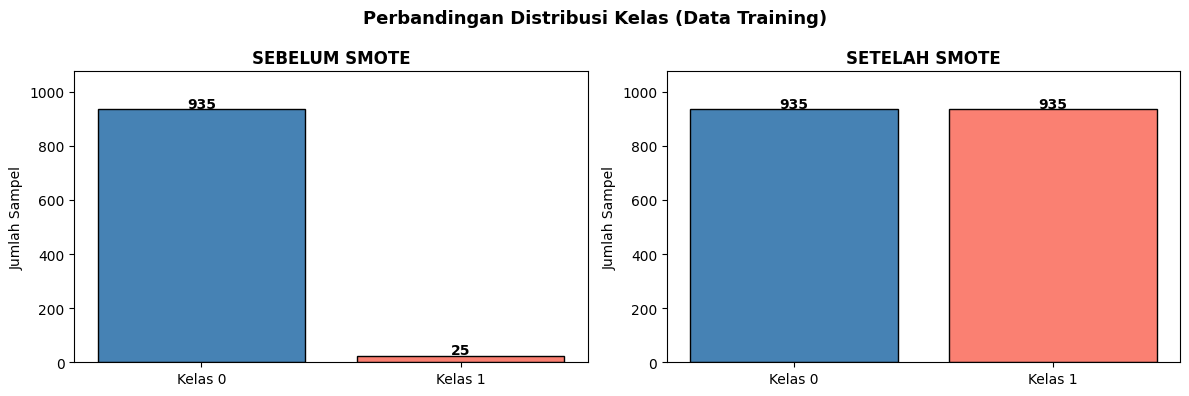


  Data train sebelum SMOTE : 960 sampel
  Data train setelah SMOTE  : 1870 sampel
  ⚠️  Data test TIDAK diubah (tetap data asli untuk evaluasi realistis)


In [9]:
print('Distribusi kelas SEBELUM SMOTE:')
print(f'  {Counter(y_train)}')

# Apply SMOTE hanya pada data training
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print()
print('Distribusi kelas SETELAH SMOTE:')
print(f'  {Counter(y_train_smote)}')

# Visualisasi perbandingan sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = pd.Series(y_train).value_counts()
after  = pd.Series(y_train_smote).value_counts()

axes[0].bar(['Kelas 0', 'Kelas 1'], before.values,
            color=['steelblue', 'salmon'], edgecolor='black')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('SEBELUM SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(after.values) * 1.15)

axes[1].bar(['Kelas 0', 'Kelas 1'], after.values,
            color=['steelblue', 'salmon'], edgecolor='black')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].set_title('SETELAH SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, max(after.values) * 1.15)

plt.suptitle('Perbandingan Distribusi Kelas (Data Training)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n  Data train sebelum SMOTE : {X_train.shape[0]} sampel')
print(f'  Data train setelah SMOTE  : {X_train_smote.shape[0]} sampel')
print('  ⚠️  Data test TIDAK diubah (tetap data asli untuk evaluasi realistis)')

---
## 🚀 Cell 7 — Training Model XGBoost

In [10]:
xgb_model = xgb.XGBClassifier(
    n_estimators    = 200,
    max_depth       = 5,
    learning_rate   = 0.1,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    eval_metric     = 'logloss',
    random_state    = 42,
    verbosity       = 0
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_train_smote, y_train_smote), (X_test, y_test)],
    verbose=False
)

print('✅ Model XGBoost selesai dilatih!')
print(f'   Jumlah estimator (pohon) : {xgb_model.n_estimators}')
print(f'   Max depth                : {xgb_model.max_depth}')
print(f'   Learning rate            : {xgb_model.learning_rate}')

✅ Model XGBoost selesai dilatih!
   Jumlah estimator (pohon) : 200
   Max depth                : 5
   Learning rate            : 0.1


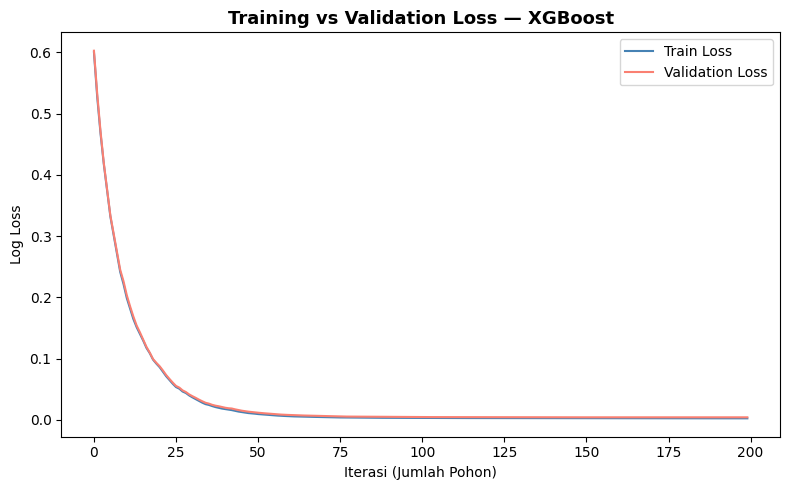

In [11]:
# Plot Logloss Kurva Training vs Validation
results = xgb_model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(results['validation_0']['logloss'], label='Train Loss', color='steelblue')
plt.plot(results['validation_1']['logloss'], label='Validation Loss', color='salmon')
plt.xlabel('Iterasi (Jumlah Pohon)')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss — XGBoost', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 📊 Cell 8 — Evaluasi Model

In [12]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('       HASIL EVALUASI — XGBoost + SMOTE')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 45)
print()
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Tidak Depresi (0)', 'Depresi (1)']))

       HASIL EVALUASI — XGBoost + SMOTE
  Accuracy  : 1.0000 (100.00%)
  ROC-AUC   : 1.0000

--- Classification Report ---
                   precision    recall  f1-score   support

Tidak Depresi (0)       1.00      1.00      1.00       234
      Depresi (1)       1.00      1.00      1.00         6

         accuracy                           1.00       240
        macro avg       1.00      1.00      1.00       240
     weighted avg       1.00      1.00      1.00       240



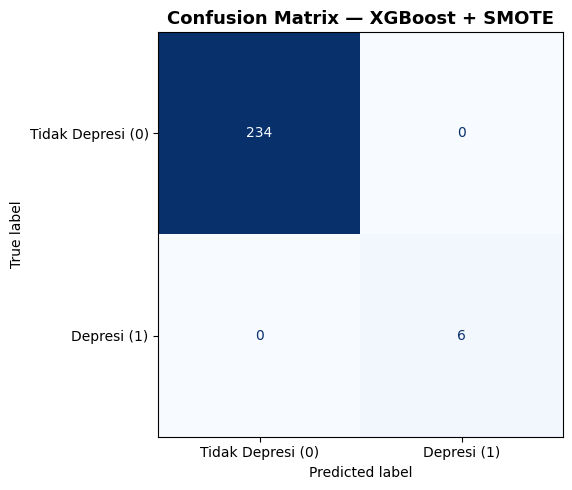

  True Negative  (TN) : 234  → Tidak Depresi, diprediksi benar
  False Positive (FP) : 0  → Tidak Depresi, diprediksi Depresi
  False Negative (FN) : 0  → Depresi, diprediksi Tidak Depresi
  True Positive  (TP) : 6  → Depresi, diprediksi benar


In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Tidak Depresi (0)', 'Depresi (1)']
)
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix — XGBoost + SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  True Negative  (TN) : {tn}  → Tidak Depresi, diprediksi benar')
print(f'  False Positive (FP) : {fp}  → Tidak Depresi, diprediksi Depresi')
print(f'  False Negative (FN) : {fn}  → Depresi, diprediksi Tidak Depresi')
print(f'  True Positive  (TP) : {tp}  → Depresi, diprediksi benar')

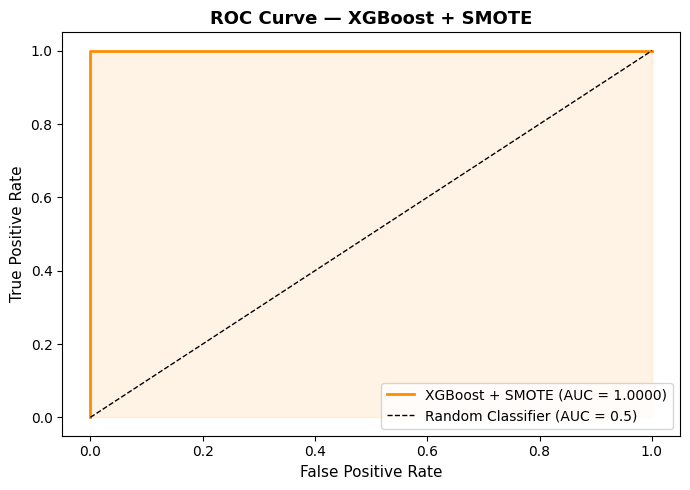

In [14]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'XGBoost + SMOTE (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve — XGBoost + SMOTE', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 🌟 Cell 9 — Feature Importance

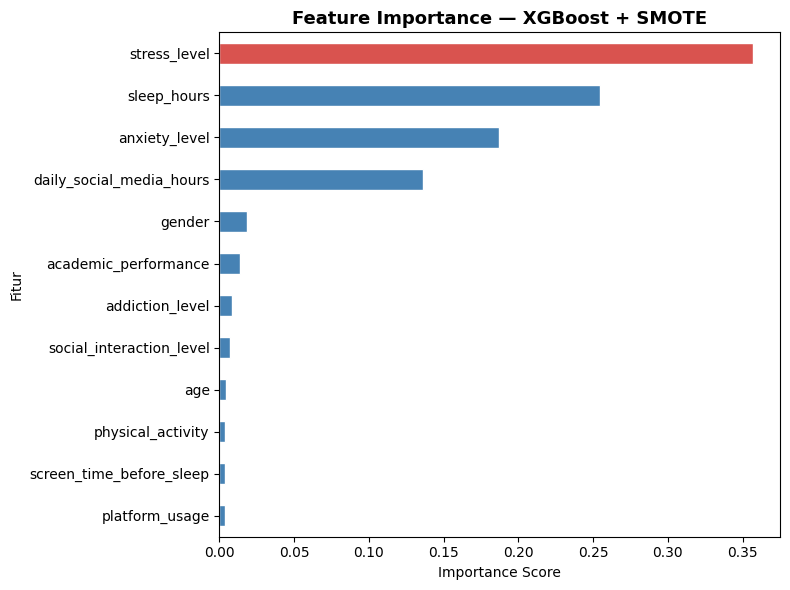

--- Ranking Fitur Terpenting ---
   1. stress_level                   : 0.3572
   2. sleep_hours                    : 0.2547
   3. anxiety_level                  : 0.1873
   4. daily_social_media_hours       : 0.1359
   5. gender                         : 0.0187
   6. academic_performance           : 0.0139
   7. addiction_level                : 0.0086
   8. social_interaction_level       : 0.0073
   9. age                            : 0.0046
  10. physical_activity              : 0.0041
  11. screen_time_before_sleep       : 0.0039
  12. platform_usage                 : 0.0039


In [15]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = ['#d9534f' if v == feat_imp.max() else 'steelblue' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — XGBoost + SMOTE', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print('--- Ranking Fitur Terpenting ---')
for rank, (feat, score) in enumerate(feat_imp.sort_values(ascending=False).items(), 1):
    print(f'  {rank:2}. {feat:<30} : {score:.4f}')

---
## 🔄 Cell 10 — Cross Validation (5-Fold Stratified)

     CROSS VALIDATION (5-Fold Stratified)
  Accuracy per fold : ['1.0000', '0.9958', '1.0000', '1.0000', '0.9958']
  Mean Accuracy     : 0.9983 ± 0.0020

  AUC per fold      : ['1.0000', '0.9979', '1.0000', '1.0000', '0.9896']
  Mean AUC          : 0.9975 ± 0.0040


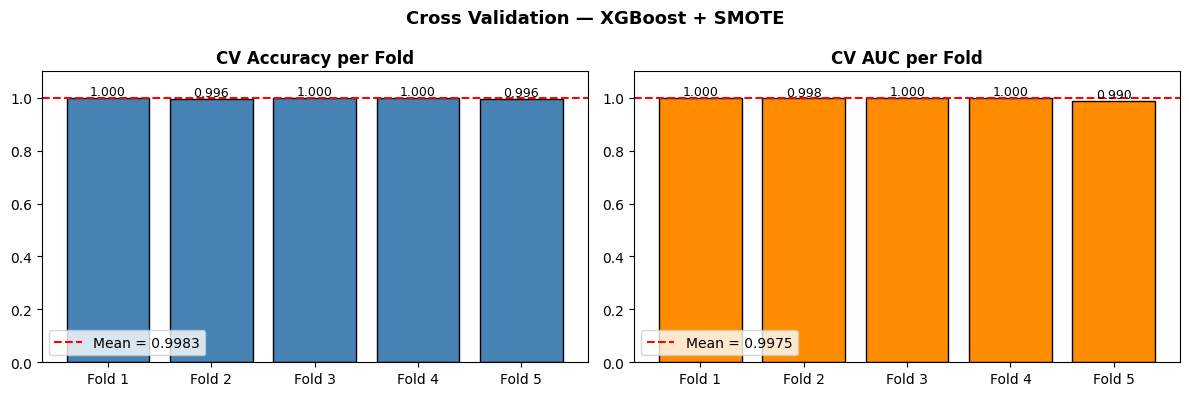

In [16]:
# Cross validation menggunakan seluruh data setelah SMOTE
# Catatan: SMOTE diterapkan di dalam pipeline untuk CV yang proper
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print('=' * 45)
print('     CROSS VALIDATION (5-Fold Stratified)')
print('=' * 45)
print(f'  Accuracy per fold : {[f"{s:.4f}" for s in cv_acc]}')
print(f'  Mean Accuracy     : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print()
print(f'  AUC per fold      : {[f"{s:.4f}" for s in cv_auc]}')
print(f'  Mean AUC          : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print('=' * 45)

# Visualisasi CV
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([f'Fold {i+1}' for i in range(5)], cv_acc,
            color='steelblue', edgecolor='black')
axes[0].axhline(cv_acc.mean(), color='red', linestyle='--', label=f'Mean = {cv_acc.mean():.4f}')
axes[0].set_title('CV Accuracy per Fold', fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
for i, v in enumerate(cv_acc):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar([f'Fold {i+1}' for i in range(5)], cv_auc,
            color='darkorange', edgecolor='black')
axes[1].axhline(cv_auc.mean(), color='red', linestyle='--', label=f'Mean = {cv_auc.mean():.4f}')
axes[1].set_title('CV AUC per Fold', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for i, v in enumerate(cv_auc):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Cross Validation — XGBoost + SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📋 Cell 11 — Ringkasan Akhir

In [17]:
print('=' * 50)
print('         RINGKASAN HASIL — XGBoost + SMOTE')
print('=' * 50)
print(f'  Dataset              : Teen Mental Health')
print(f'  Total sampel         : {len(df)}')
print(f'  Fitur                : {X.shape[1]}')
print(f'  Algoritma            : XGBoost')
print(f'  Handling Imbalance   : SMOTE')
print()
print(f'  [TEST SET]')
print(f'  Accuracy             : {acc:.4f} ({acc*100:.2f}%)')
print(f'  ROC-AUC              : {auc:.4f}')
print()
print(f'  [CROSS VALIDATION - 5 Fold]')
print(f'  Mean Accuracy        : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  Mean AUC             : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print()
top_feat = pd.Series(xgb_model.feature_importances_, index=X.columns).idxmax()
print(f'  Fitur paling penting : {top_feat}')
print('=' * 50)

         RINGKASAN HASIL — XGBoost + SMOTE
  Dataset              : Teen Mental Health
  Total sampel         : 1200
  Fitur                : 12
  Algoritma            : XGBoost
  Handling Imbalance   : SMOTE

  [TEST SET]
  Accuracy             : 1.0000 (100.00%)
  ROC-AUC              : 1.0000

  [CROSS VALIDATION - 5 Fold]
  Mean Accuracy        : 0.9983 ± 0.0020
  Mean AUC             : 0.9975 ± 0.0040

  Fitur paling penting : stress_level
